# Matplotlib and Seaborn 📈

## What you will learn in this course 🧐🧐

Visualization is a powerful tool for understanding data. In this lecture, we will cover the essentials of two popular Python libraries for data visualization: **Matplotlib** and **Seaborn**.

By the end, you will be able to:
- Understand the **figure / axes** model that underpins both libraries
- Create the core chart types: line, bar, histogram, scatter, box
- Use **Seaborn** for fast statistical plots from a tidy DataFrame
- Encode multiple variables with `hue`, `size`, `style`
- Save figures for reports and slides

<Note type="important" title="Customization is a deep topic">

Customization (themes, fonts, colors, legends) is a deep topic. We cover only what's necessary; links to full documentation are at the end.

</Note>

## Matplotlib vs Seaborn

- **Matplotlib** is the foundation. It's verbose but gives you total control.
- **Seaborn** is built on top of Matplotlib. It's concise and has statistical defaults baked in. It works directly with `pandas` DataFrames in **tidy format** (one observation per row).

We recommend starting with Seaborn for quick insights, then using Matplotlib for fine-tuning.

## Matplotlib

### Setup

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Default size for all plots (10 inches wide, 6 inches tall)
plt.rcParams['figure.figsize'] = (10, 6)

# Custom color palette used throughout the lecture
color = ["#FE0162", "#345FFF", "#0ECDD0", "#F6970A", "#0B155B"]

# Make Seaborn use the same palette by default
sns.set_palette(color)

### The Figure / Axes anatomy

Every Matplotlib plot has two key objects:

1. **Figure**: the whole window or canvas
2. **Axes**: a single plot area inside the figure (a figure can hold many)

For example, this code creates one figure with one axes:
```python
fig, ax = plt.subplots()   # one figure, one axes
ax.plot(...)
ax.set_title(...)
```

This pattern scales to multiple subplots without changing your style. For example, this creates a 2x2 grid of axes:

```python
fig, axes = plt.subplots(2, 2)   # 2x2 grid of axes
axes[0, 0].plot(...)
```

### Differents type of plots 

#### Line plot 
The line plot is the most basic and versatile chart type. It connects data points with a line, making it ideal for showing **trends over time** or **continuous data**.

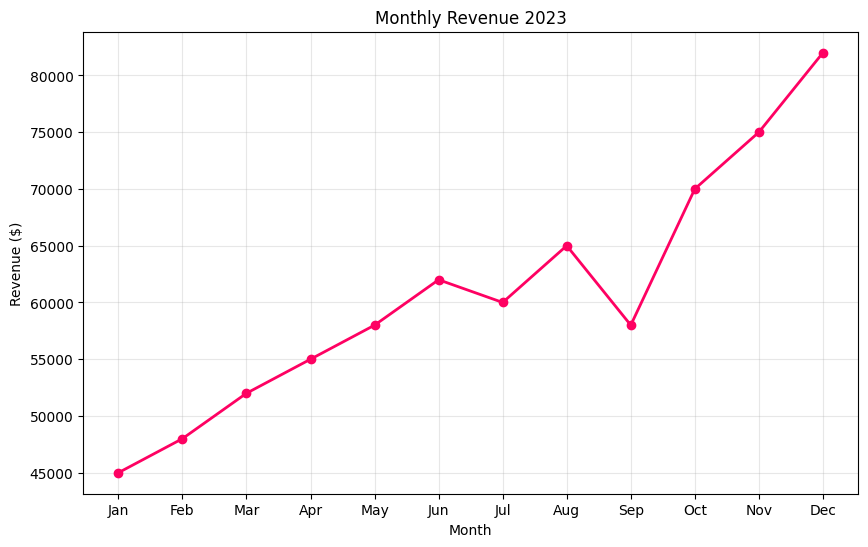

In [2]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
revenue = [45000, 48000, 52000, 55000, 58000, 62000,
           60000, 65000, 58000, 70000, 75000, 82000]

fig, ax = plt.subplots()
# Line plot with markers, custom line width, and color
ax.plot(months, revenue, marker='o', linewidth=2, color=color[0])
# Add title, labels, and grid with custom alpha for lighter lines
ax.set_title('Monthly Revenue 2023')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')
ax.grid(True, alpha=0.3)
# Show the plot
plt.show()

**Interpretation**

Monthly revenue shows a clear upward trend across 2023, almost doubling from \$45k in January to \$82k in December. Growth is not perfectly linear: there is a noticeable dip in July (after a strong June) and another in September. December is the standout month, suggesting holiday-season demand. Overall the business is on a healthy growth trajectory, but the two intra-year dips are worth investigating (seasonality, supply issue, or marketing pause?).

#### Bar chart
The bar chart is used to compare **categorical data**. Each bar represents a category, and the height of the bar corresponds to the value of that category.

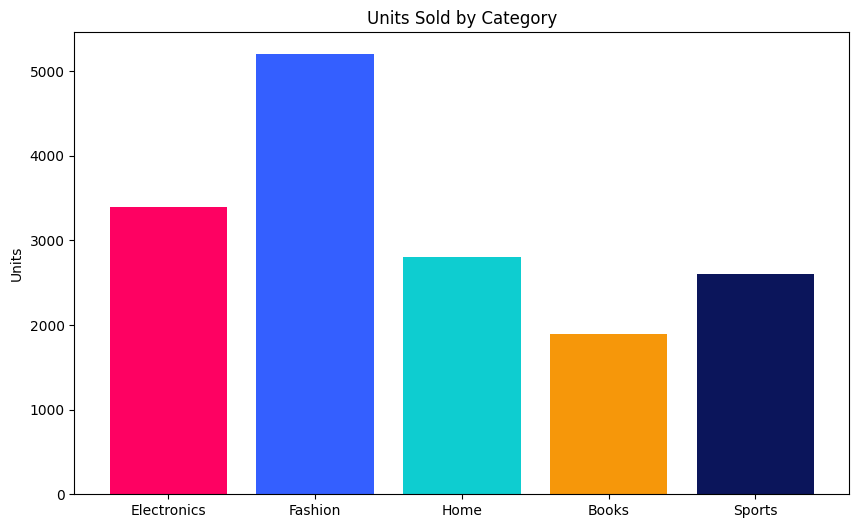

In [3]:
categories = ['Electronics', 'Fashion', 'Home', 'Books', 'Sports']
units_sold = [3400, 5200, 2800, 1900, 2600]

fig, ax = plt.subplots()
# Bar chart - one color per category from our palette
ax.bar(categories, units_sold, color=color)
ax.set_title('Units Sold by Category')
ax.set_ylabel('Units')
plt.show()

**Interpretation**

Fashion is the top-selling category with 5,200 units, well ahead of Electronics in second place (3,400). Books is the clear underperformer at only 1,900 units, roughly a third of Fashion. Home and Sports sit in the middle of the pack with similar volumes (~2,600–2,800). This kind of view is useful for inventory and marketing decisions: more shelf space and ad budget probably belongs on Fashion, while Books may need a strategy review.

#### Histogram 
The histogram is used to visualize the **distribution of numerical data**. It divides the data into bins and shows the frequency of values in each bin.

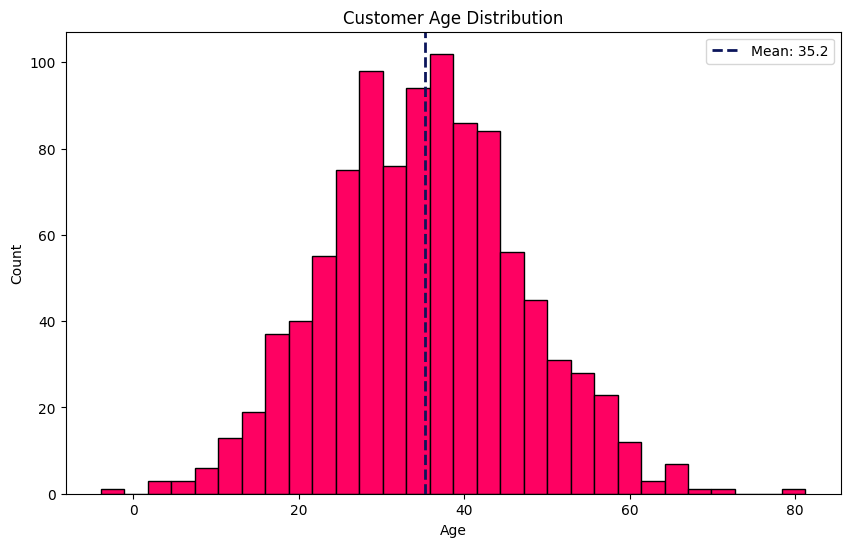

In [4]:
np.random.seed(42)

# Generate 1000 random ages with a normal distribution (mean=35, std=12)
ages = np.random.normal(35, 12, 1000)

fig, ax = plt.subplots()
# Histogram with 30 bins, custom color, and black edges
ax.hist(ages, bins=30, color=color[0], edgecolor='black')
# Add a vertical line for the mean age
ax.axvline(ages.mean(), color=color[4], linestyle='--', linewidth=2, label=f'Mean: {ages.mean():.1f}')
ax.set_title('Customer Age Distribution')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
# Add legend for the mean line
ax.legend()
plt.show()

**Interpretation**

The customer age distribution is roughly bell-shaped (normal), centered around the mean of ~35 years. Most customers fall between 23 and 47 years old (one standard deviation either side of the mean). The distribution is fairly symmetric (there is no obvious skew toward younger or older buyers), so marketing aimed at the broad 25–45 segment would reach the bulk of the customer base. The tails are thin: very few customers are under 10 or over 60.

#### Scatter plot

The scatter plot is used to show the **relationship between two numerical variables**. Each point represents an observation, with its position determined by the values of the two variables.

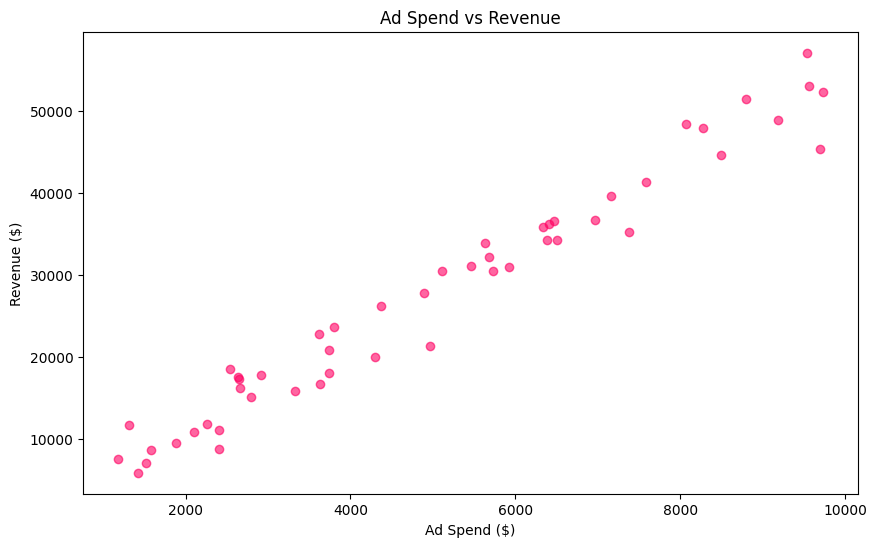

In [5]:
np.random.seed(42)
# Generate 50 random ad spend values between $1000 and $10000
ad_spend = np.random.uniform(1000, 10000, 50)
# Generate revenue with a positive correlation to ad spend, plus some random noise
revenue_scatter = ad_spend * 5.5 + np.random.normal(0, 3000, 50)

fig, ax = plt.subplots()
# Scatter plot with custom color and alpha for better visibility
ax.scatter(ad_spend, revenue_scatter, alpha=0.6, color=color[0])
ax.set_title('Ad Spend vs Revenue')
ax.set_xlabel('Ad Spend ($)')
ax.set_ylabel('Revenue ($)')
plt.show()

**Interpretation**

There is a strong positive linear relationship between ad spend and revenue: as advertising budget increases, revenue rises roughly proportionally. The scatter around that trend (the vertical spread at any given x) reflects noise. Other factors influence revenue beyond ad spend alone. This kind of plot is the visual starting point for a regression analysis: the slope of the underlying line is essentially the *return on ad spend* (here, about \$5.5 of revenue per \$1 invested).

### Multiple plots 

When you need to compare several views in one figure, ask `plt.subplots()` for a grid. You get a 2D array of axes back.

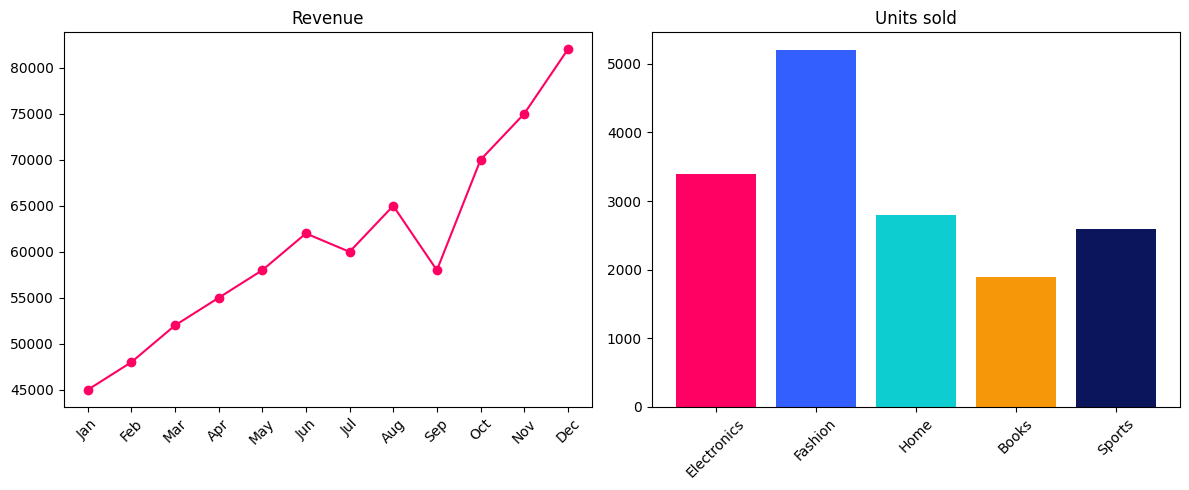

In [6]:
# Create a figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left subplot: Line plot for revenue
axes[0].plot(months, revenue, marker='o', color=color[0])
axes[0].set_title('Revenue')
axes[0].tick_params(axis='x', rotation=45)

# Right subplot: Bar chart for units sold (one color per category)
axes[1].bar(categories, units_sold, color=color)
axes[1].set_title('Units sold')
axes[1].tick_params(axis='x', rotation=45)

# Adjust layout to prevent overlap and show the combined figure
plt.tight_layout()
plt.show()

**Interpretation**

Side-by-side, these two views answer two different questions about the same business. The left panel tracks *time*: revenue is growing month over month. The right panel breaks down *what is being sold*: Fashion dominates unit volume. Putting them next to each other is the point of subplots: a stakeholder can read the trend and the category mix in one glance, instead of flipping between two figures.

### Saving a figure

To export your plot, use `plt.savefig()`. This function writes the figure to disk. Use `dpi=300` for print-quality PNG, and `bbox_inches='tight'` to trim whitespace.

Automatically, Matplotlib saves in vector format (PDF, SVG) which scales infinitely without losing quality. For raster formats (PNG, JPG), you can specify the resolution with `dpi`.

```python
fig.savefig('revenue.png', dpi=300, bbox_inches='tight')
fig.savefig('revenue.pdf', bbox_inches='tight')   # vector, scales infinitely
```

## Seaborn

Seaborn ships with example datasets so you can experiment without loading anything.

Let's load some of them:

- `tips` dataset, which contains information about restaurant bills and tips
- `flights` dataset, which contains monthly passenger numbers for an airline
- `iris` dataset, which contains measurements of iris flowers

<Note type="important" title="Tidy data format">
Seaborn works best with data in a "tidy" format, where each column is a variable and each row is an observation. To see the list of available datasets, run `sns.get_dataset_names()`.
</Note>

In [7]:
# sns.get_dataset_names()

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset('tips')        # restaurant bills & tips
flights = sns.load_dataset('flights')  # monthly passengers 1949-1960
iris = sns.load_dataset('iris')        # flower measurements

tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### The three workhorse plot types

For most analyses, you'll reach for one of **three categories** of plots in Seaborn:

| Question | Plot type | Function |
|---|---|---|
| How do two numeric variables relate? | scatter / line | `sns.scatterplot`, `sns.lineplot` |
| What does the distribution look like? | hist / kde | `sns.histplot`, `sns.kdeplot` |
| How does a numeric variable differ across categories? | box / violin / bar | `sns.boxplot`, `sns.violinplot`, `sns.barplot` |

You can pass a column name to `hue`, `size`, or `style` to encode extra variables on the same plot.

### Scatter plot with multi-dimensional encoding

For example, this code creates a scatter plot of `total_bill` vs `tip`, with points colored by `time` (lunch/dinner), sized by `size` (party size), and shaped by `sex` (male/female):

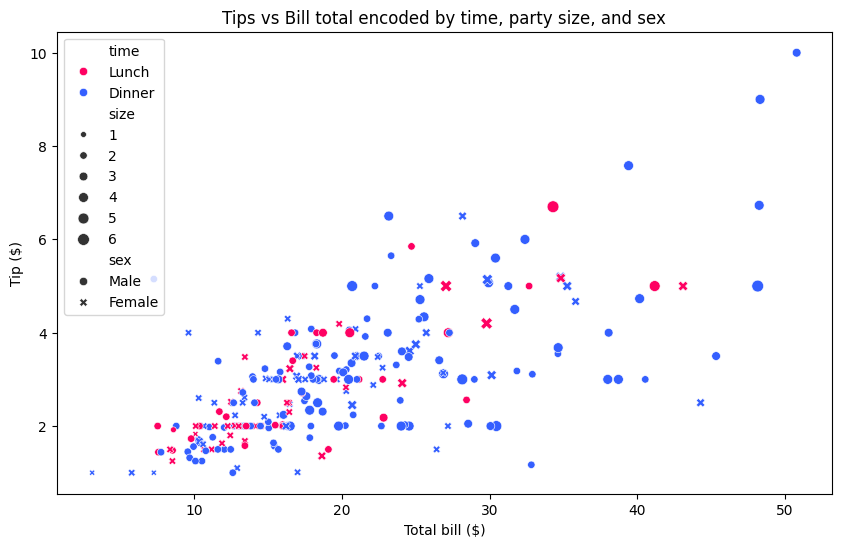

In [9]:
sns.scatterplot(
    data=tips,
    x='total_bill', y='tip',
    hue='time',     # color by lunch/dinner
    size='size',    # marker size by party size
    style='sex',    # marker shape by sex
    palette=color[:2]
)
plt.title('Tips vs Bill total encoded by time, party size, and sex')
plt.xlabel('Total bill ($)')
plt.ylabel('Tip ($)')
plt.show()

**Interpretation**

Tip amount rises with the total bill, the classic positive correlation, since tipping is generally a percentage of the check. Larger parties (bigger markers) tend to cluster at higher bill totals, which is unsurprising. The split between lunch and dinner (color) shows that dinner bills span a much wider range than lunch, while lunch bills are concentrated at the lower end. Differences in tipping behavior between male and female payers (shape) are not visually striking; they appear mixed throughout.

#### Line plot 

With `sns.lineplot()`, you can easily plot trends over time. For example, using the `flights` dataset, you can plot the number of passengers over time and add a confidence interval to show the variability in the data:

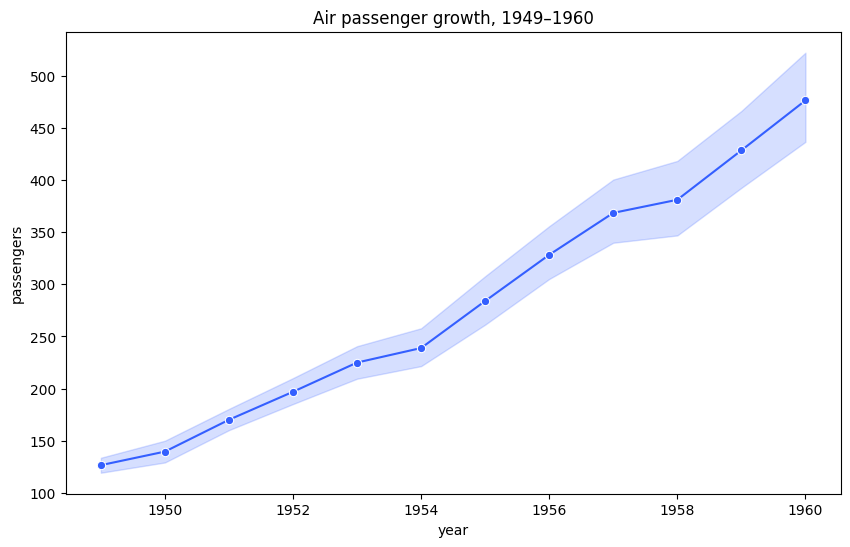

In [10]:
sns.lineplot(data=flights, x='year', y='passengers', marker='o', color=color[1])
plt.title('Air passenger growth, 1949–1960')
plt.show()

**Interpretation**

Air passenger volume grew steadily from 1949 to 1960, more than tripling over the period. The shaded band around the line is Seaborn's automatic 95% confidence interval, and it is wider in some years, reflecting larger month-to-month variation within that year (i.e. stronger seasonality). The trend is unmistakably exponential-looking, consistent with the post-war boom in commercial aviation.

### Histogram

To compare distributions across categories, you can use `hue` to color the histogram by a categorical variable. For example, this code plots the distribution of `total_bill` for lunch and dinner:

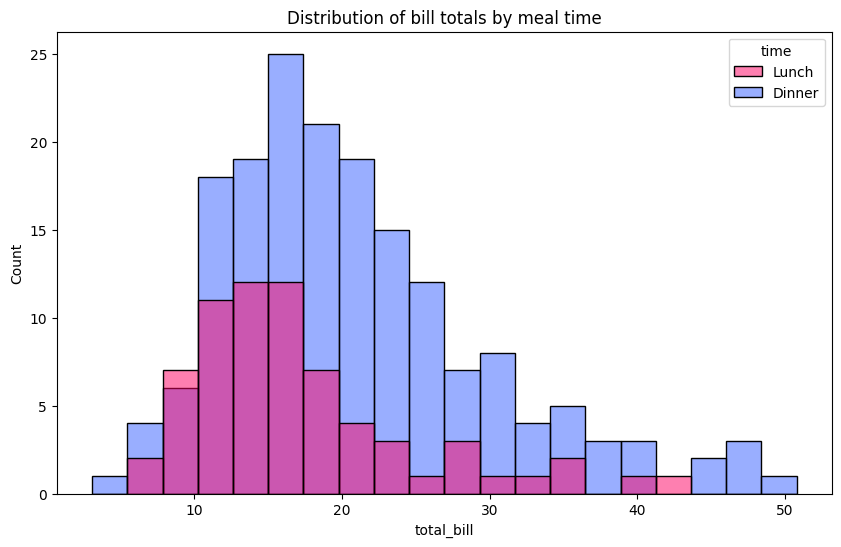

In [11]:
sns.histplot(data=tips, x='total_bill', bins=20, hue='time', palette=color[:2])
plt.title('Distribution of bill totals by meal time')
plt.show()

**Interpretation**

Dinner bills dominate the dataset. There are far more dinner observations than lunch ones, and the dinner distribution stretches further to the right (larger bills). Lunch bills are concentrated in the lower range (mostly under \$20), while dinner bills are more spread out, with a long right tail of expensive checks. The takeaway: the restaurant earns more both in volume and per-check during dinner service.

### Box plot 

The box plot is a great way to compare the distribution of a numeric variable across categories. It shows the median, quartiles, and outliers. For example, this code compares `total_bill` across different `day`s of the week:

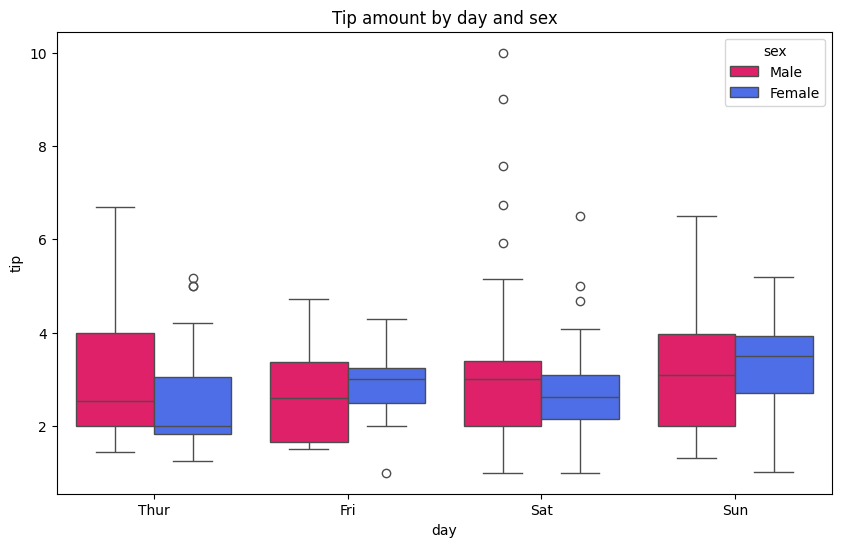

In [12]:
sns.boxplot(data=tips, x='day', y='tip', hue='sex', palette=color[:2])
plt.title('Tip amount by day and sex')
plt.show()

**Interpretation**

Median tips are fairly similar across days (around \$2.50–\$3) and between male and female payers. The most striking feature is the spread: weekend boxes (Saturday, Sunday) are taller than weekday boxes, meaning tip amounts vary more on weekends. Sunday in particular shows a few high outliers, likely larger parties or generous tippers. Male and female tip distributions overlap heavily, suggesting sex is not a strong driver of tip amount in this dataset.

The box shows the interquartile range (25th–75th percentile), the line inside is the median, and points beyond the whiskers are **outliers**.

<Note type="tip" title="Outliers">
Outliers are data points that fall significantly outside the range of the rest of the data. They can indicate variability in the data, errors, or interesting phenomena that warrant further investigation.
</Note>

### Pairplot 

When you receive a new dataset, `pairplot` gives you every pairwise relationship at once. Use it for *exploration*, not for final reports. It only works with **numeric variables**, so it will automatically ignore categorical columns. You can use `hue` to color points by a categorical variable. Here is an example using the `iris` dataset to visualize the relationships between the four measurements (sepal length, sepal width, petal length, petal width), colored by species:

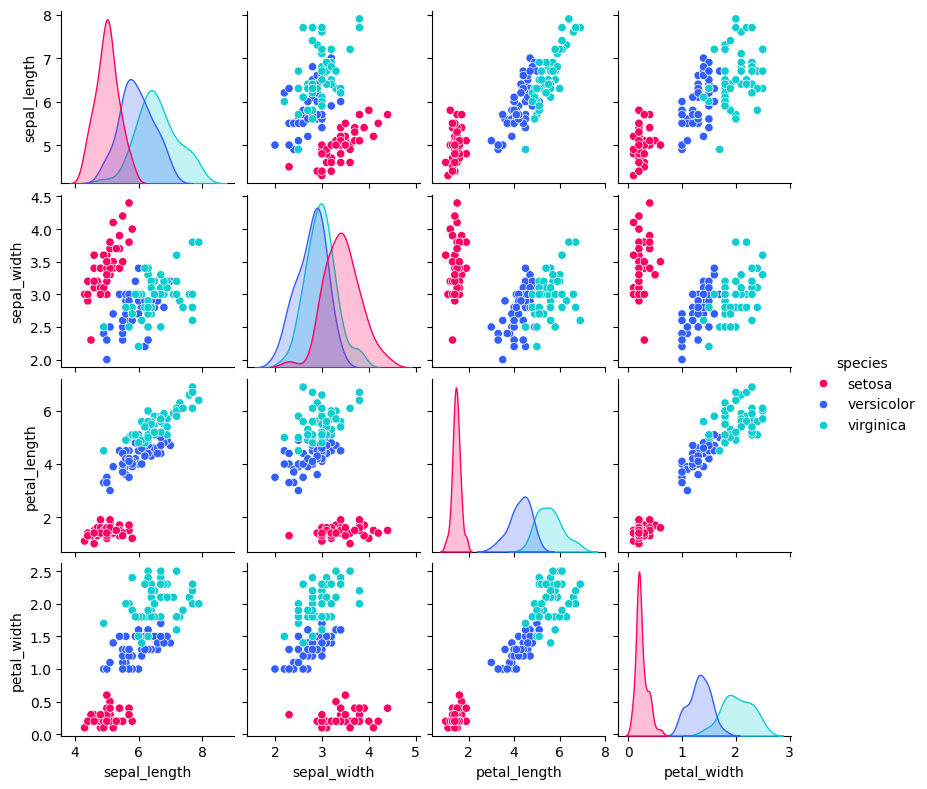

In [13]:
sns.pairplot(iris, hue='species', diag_kind='kde', height=2, palette=color[:3])
plt.show()

**Interpretation**

The pairplot shows every pairwise combination of the four iris measurements, colored by species. A few clear patterns:

- *Setosa* (one color) is linearly separable from the other two species on almost every panel; its petal length and petal width are distinctly smaller.
- *Versicolor* and *Virginica* overlap more, but petal length and petal width still separate them reasonably well.
- The diagonal KDEs confirm this visually: petal-related features have well-separated peaks per species, while sepal-related features overlap more.

This is why the iris dataset is a classic teaching example: even a simple classifier on petal length/width achieves near-perfect accuracy.

## Mixing Seaborn with Matplotlib

Every Seaborn function returns a Matplotlib axes. You can pass an existing axes via `ax=`, or call `plt.*` functions afterwards to tweak titles, labels, limits, etc.


(0.0, 60.0)

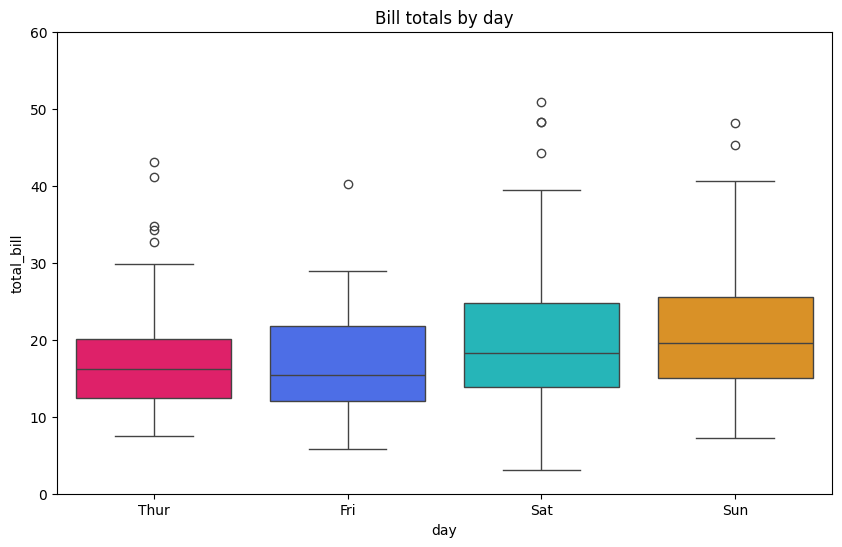

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=tips, x='day', y='total_bill', hue='day', ax=ax, palette=color[:4], legend=False)
ax.set_title('Bill totals by day')
ax.set_ylim(0, 60)

**Interpretation**

Saturday and Sunday have the highest median bill totals and the widest spread, typical weekend behavior, with longer meals and larger groups driving bigger checks. Thursday and Friday are noticeably lower and more compact. The handful of points beyond the upper whiskers are outlier tables (very expensive bills), most of which appear on weekend days. This complements what we saw in the tip boxplot: weekends bring both higher bills and more variable tipping.

Anytime Seaborn doesn't expose the option you need, drop into Matplotlib. 

## Resources 📚📚

- [Official tutorials](https://matplotlib.org/stable/tutorials/index.html) 
- [Gallery of examples](https://matplotlib.org/stable/gallery/index.html) 
- [Colormaps reference](https://matplotlib.org/stable/users/explain/colors/colormaps.html)
- [Style sheets](https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html)
- [Seaborn Official user guide](https://seaborn.pydata.org/tutorial.html)
- [API reference with examples](https://seaborn.pydata.org/api.html)
- [Figure-level vs axes-level functions](https://seaborn.pydata.org/tutorial/function_overview.html)
- [FacetGrid](https://seaborn.pydata.org/generated/seaborn.FacetGrid.html) 